In [6]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

#loading cleaned income dataset
income = pd.read_csv("cleaned/va_county_median_household_income.csv")

#loading datacenter dataset 
dc = pd.read_csv("cleaned/VA_DataCenters.csv")

print(income.head())
print(dc.head())

             county  median_household_income
0   Accomack County                    58993
1  Albemarle County                   104392
2   Alexandria city                   119681
3  Alleghany County                    56188
4     Amelia County                    76717
                     DATA_CENTER_BUILDING_NAME  PROVIDER_NAME  TOT_POWER_MW  \
0                Enterprise Data Center 1 NoVa   Carter Funds        8.4977   
1               Clarksville - AI Data Center 1     TECfusions       80.0000   
2                           VIN1 Data Center 1       OVHCloud       12.0000   
3  Amazon AWS IAD - John Marshall 2 Building 1  Black Chamber       60.0000   
4              Gainesville Crossing Building 2       Corscale       72.0000   

                  County  
0         Loudoun County  
1     Mecklenburg County  
2         Loudoun County  
3         Loudoun County  
4  Prince William County  


In [20]:
#making everything lowercase to ensure matching works 
dc = dc.rename(columns={'County': 'county'})

income['county'] = income['county'].str.lower()
dc['county'] = dc['county'].str.lower()


In [25]:
#counting number of datasets per county 
dc_counts = dc.groupby('county').size().reset_index(name='num_datacenters')

df = pd.merge(income, dc_counts, on='county', how='inner')

print(df.head())

              county  median_household_income  num_datacenters
0   albemarle county                   104392                1
1  appomattox county                    62853                1
2   arlington county                   142114               10
3    campbell county                    66165                3
4    caroline county                    87407                2


In [30]:
#creating affluent variable 

#computing median income threshold across aounties 
threshold = df['median_household_income'].median()

#creating binary variable where 1 = affluent, 0 = non-affluent 
df['affluent'] = (df['median_household_income'] > threshold).astype(int)

#checking distribution of groups 
print(df['affluent'].value_counts())

affluent
1    11
0    11
Name: count, dtype: int64


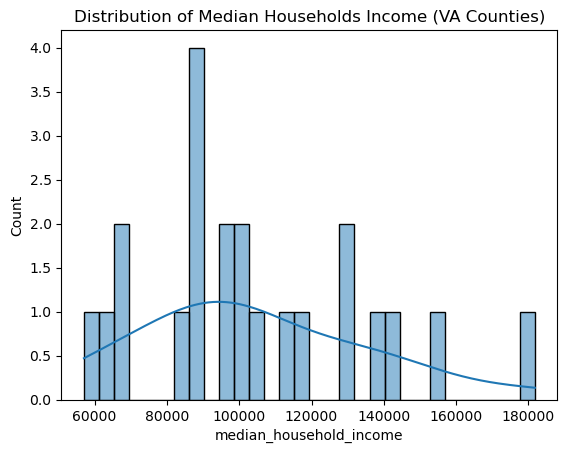

In [31]:
#income distribution visual 

#distribution of income across counties 
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.histplot(df['median_household_income'], bins=30, kde=True)
plt.title("Distribution of Median Households Income (VA Counties)")
plt.show()

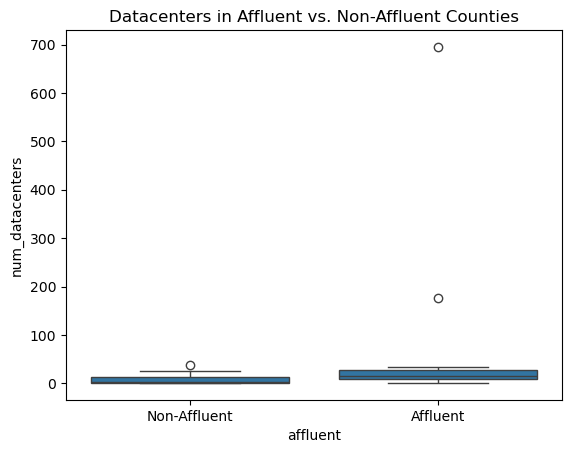

In [32]:
#boxplot comparison of datacenters by affluence 
sns.boxplot(x='affluent', y='num_datacenters', data=df)
plt.xticks([0,1], ['Non-Affluent', 'Affluent'])
plt.title("Datacenters in Affluent vs. Non-Affluent Counties")
plt.show()


In [33]:
#numeric summary 

#average number of datacenters by group 
print(df.groupby('affluent')['num_datacenters'].mean())

affluent
0     8.909091
1    90.909091
Name: num_datacenters, dtype: float64


In [34]:
#correlation 
print(df[['median_household_income', 'num_datacenters']].corr())

                         median_household_income  num_datacenters
median_household_income                 1.000000         0.597105
num_datacenters                         0.597105         1.000000
